# Tech Challenge – Fase 3: Predição e Inteligência Analítica para Alfabetização no Brasil

---

### **Caderno 01: Análise Exploratória de Dados (EDA) e Formulação de Hipóteses**
**Objetivo:** Explorar a base de dados integrada da **Camada Gold** (10.704 registros correspondentes aos 5.352 municípios brasileiros nos anos de 2023 e 2024), diagnosticar a qualidade dos dados, compreender padrões socioeconômicos e estruturais, testar hipóteses analíticas estatisticamente e mapear riscos de *Data Leakage* para subsidiar a pipeline preditiva de Machine Learning.



In [15]:
# Importação de bibliotecas analíticas essenciais
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações de exibição e gráficos
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14,
    'figure.autolayout': True
})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## 1. Carregamento e Visão Geral da Base da Camada Gold

In [16]:
try:
    df = pd.read_csv('../data/raw/Data.csv')
except FileNotFoundError:
    df = pd.read_csv('Data.csv')

linhas, colunas = df.shape
print(f"Dimensões: {linhas:,} linhas x {colunas} colunas")
print(f"Anos de Coleta: {sorted(df['ano'].unique())}")
print(f"Municípios Únicos: {df['id_municipio'].nunique():,}")

df.head(3)


Dimensões: 10,704 linhas x 36 colunas
Anos de Coleta: [2023, 2024]
Municípios Únicos: 5,352


,ano,id_municipio,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,percentual_participacao,gap_meta_2030,status_meta_2030,classe_taxa,nome_municipio,sigla_uf,nome_uf,nome_regiao,capital_uf,amazonia_legal,populacao,pib,pib_per_capita,qtd_escolas,matriculas_anos_iniciais,docentes_anos_iniciais,razao_aluno_docente,pct_escolas_internet,pct_escolas_biblioteca,pct_escolas_lab_informatica,pct_escolas_agua_potavel,pct_escolas_energia_publica,pct_escolas_esgoto_publico,pct_escolas_quadra_esportes,computadores_por_aluno
0,2024,4301750,4.400,NaN,14.050,23.650,37.000,52.680,67.850,80.000,0.000,92.590,-75.600,abaixo_meta_2030,muito_baixo,Barão do Triunfo,RS,Rio Grande do Sul,Sul,0,0,5983,NaN,NaN,5,371,41,9.049,1.000,0.400,0.000,1.000,1.000,0.000,0.600,NaN
1,2023,4301750,NaN,NaN,14.050,23.650,37.000,52.680,67.850,80.000,NaN,NaN,NaN,sem_dado,sem_dado,Barão do Triunfo,RS,Rio Grande do Sul,Sul,0,0,5889,142447000.000,24188.657,8,279,31,9.000,1.000,0.400,0.000,1.000,1.000,0.000,0.600,NaN
2,2024,2406908,42.860,7.940,14.050,23.650,37.000,52.680,67.850,80.000,1.000,84.000,-37.140,abaixo_meta_2030,baixo,Lucrécia,RN,Rio Grande do Norte,Nordeste,0,0,3579,NaN,NaN,6,185,10,18.500,1.000,0.250,0.250,1.000,1.000,0.500,0.000,NaN


## 2. Taxonomia e Dicionário de Variáveis

As 36 variáveis foram integradas na Fase 2 a partir de bases oficiais (Censo Escolar/INEP, Compromisso Criança Alfabetizada/MEC, IBGE). Elas se agrupam em 6 blocos analíticos:

| Bloco | Variáveis | Papel Analítico |
| :--- | :--- | :--- |
| **Identificadores Territoriais** | `id_municipio`, `nome_municipio`, `sigla_uf`, `nome_uf`, `nome_regiao`, `capital_uf`, `amazonia_legal` | Estratificação espacial e controle regional |
| **Temporais** | `ano` (2023, 2024) | Séries temporais e medição de evolução anual |
| **Socioeconômicos** | `populacao`, `pib`, `pib_per_capita` | Capacidade fiscal e contexto demográfico |
| **Estrutura Escolar** | `qtd_escolas`, `matriculas_anos_iniciais`, `docentes_anos_iniciais`, `razao_aluno_docente` | Porte da rede e densidade de atendimento |
| **Infraestrutura das Escolas** | `% internet`, `% biblioteca`, `% lab_info`, `% água potável`, `% energia`, `% esgoto`, `% quadra`, `computadores/aluno` | Condições físicas de suporte ao aprendizado |
| **Avaliação & Metas** | `taxa_alfabetizacao`, `meta_2024` a `meta_2030`, `nivel_alfabetizacao`, `percentual_participacao`, `gap_meta_2030`, `status_meta_2030`, `classe_taxa` | Indicadores de desempenho e acompanhamento |


## 3. Diagnóstico Crítico de Qualidade e Valores Faltantes (*Missing Values*)

In [17]:
# Cálculo detalhado de dados faltantes por coluna e por ano
missing_data = []
for col in df.columns:
    tot_null = df[col].isnull().sum()
    pct_null = (tot_null / len(df)) * 100
    null_2023 = df[df['ano'] == 2023][col].isnull().sum()
    null_2024 = df[df['ano'] == 2024][col].isnull().sum()
    if tot_null > 0:
        missing_data.append({
            'Coluna': col,
            'Tipo': str(df[col].dtype),
            'Total Nulos': tot_null,
            '% Nulo': pct_null,
            'Nulos em 2023': null_2023,
            'Nulos em 2024': null_2024
        })

df_missing = pd.DataFrame(missing_data).sort_values(by='Total Nulos', ascending=False)
df_missing.reset_index(drop=True)


,Coluna,Tipo,Total Nulos,% Nulo,Nulos em 2023,Nulos em 2024
0,computadores_por_aluno,float64,10704,100.000,5352,5352
1,pib,float64,5352,50.000,0,5352
2,pib_per_capita,float64,5352,50.000,0,5352
3,meta_alfabetizacao_2024,float64,240,2.242,120,120
4,taxa_alfabetizacao,float64,120,1.121,120,0
5,nivel_alfabetizacao,float64,120,1.121,120,0
6,percentual_participacao,float64,120,1.121,120,0
7,gap_meta_2030,float64,120,1.121,120,0


### Conclusões Críticas sobre os Dados Faltantes:
1. **`computadores_por_aluno` (100% nulo)**: A variável não foi preenchida em nenhum município em 2023 nem 2024. Deve ser descartada do espaço de features por ausência total de informação.
2. **`pib` e `pib_per_capita` (50% nulo - 100% do ano 2024)**: O IBGE divulga o PIB municipal com defasagem histórica de 2 anos (PIB 2023 publicado recentemente, PIB 2024 ainda não apurado).
   - *Solução metodológica para Machine Learning*: Na modelagem preditiva de 2024, pode-se realizar *forward-fill* do PIB 2023 ajustado pela variação populacional de 2023 para 2024.
3. **`taxa_alfabetizacao`, `nivel_alfabetizacao`, `gap_meta_2030` (120 nulos em 2023)**: Correspondem a 120 municípios (`status_meta_2030 == 'sem_dado'`) que não atingiram a taxa mínima de participação exigida pelo Inep (quórum mínimo de alunos) para validação estatística da amostra. Em 2024, todos os 5.352 municípios possuem taxa válida.
4. **`meta_alfabetizacao_2024` (240 nulos)**: Municípios que não pactuaram meta específica no primeiro ciclo.


## 4. Mapeamento Preventivo de Vazamento de Dados (*Data Leakage*)

> **ATENÇÃO METODOLÓGICA**: Para construir modelos supervisionados com generalização real, as seguintes variáveis **NÃO** podem ser utilizadas como preditoras:
> - **`gap_meta_2030`**: É uma conta feita com a própria taxa. Usá-la dá a resposta exata ao modelo
> - **`classe_taxa` e `nivel_alfabetizacao`**: São apenas a própria taxa dividida em grupos
> - **`status_meta_2030`**: É o rótulo derivado do atingimento da meta ($Taxa \ge Meta_{2030}$).
> - **Metas Futuras (`meta_alfabetizacao_2025` a `2030`)**: Metas futuras não exercem causalidade sobre o desempenho presente e contêm projeções do próprio Inep sobre a trajetória esperada do município.


## 5. Análise por Variável: Comportamento da Taxa de Alfabetização

In [18]:
# Estatísticas descritivas por ano
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)

stats_summary = df.groupby('ano')['taxa_alfabetizacao'].agg([
    ('Contagem', 'count'),
    ('Média', 'mean'),
    ('Desvio Padrão', 'std'),
    ('Mínimo', 'min'),
    ('Q25 (1º Quartil)', q25),
    ('Mediana', 'median'),
    ('Q75 (3º Quartil)', q75),
    ('Máximo', 'max'),
    ('Assimetria', 'skew'),
    ('Curtose', pd.Series.kurt) 
])
stats_summary


,Contagem,Média,Desvio Padrão,Mínimo,Q25 (1º Quartil),Mediana,Q75 (3º Quartil),Máximo,Assimetria,Curtose
ano,,,,,,,,,,
2023,5232,60.479,19.723,4.400,46.800,60.950,75.125,100.000,-0.127,-0.581
2024,5352,63.042,19.252,4.400,48.730,64.250,77.712,100.000,-0.192,-0.678


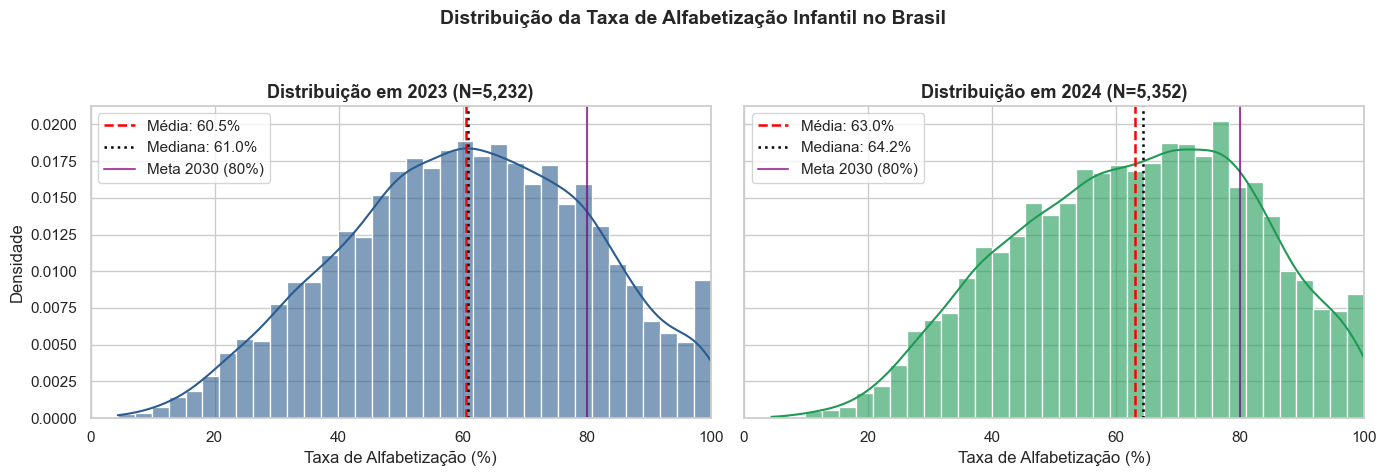

In [19]:
# Visualização da Distribuição (Histograma + KDE)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for i, y in enumerate([2023, 2024]):
    sub = df[df['ano'] == y]['taxa_alfabetizacao'].dropna()
    sns.histplot(sub, kde=True, ax=axes[i], color='#2b5c8f' if y == 2023 else '#1f9a55', bins=35, stat="density", alpha=0.6)
    axes[i].axvline(sub.mean(), color='red', linestyle='--', linewidth=1.8, label=f'Média: {sub.mean():.1f}%')
    axes[i].axvline(sub.median(), color='black', linestyle=':', linewidth=1.8, label=f'Mediana: {sub.median():.1f}%')
    axes[i].axvline(80.0, color='purple', linestyle='-', linewidth=1.5, alpha=0.7, label='Meta 2030 (80%)')
    axes[i].set_title(f'Distribuição em {y} (N={len(sub):,})', fontweight='bold')
    axes[i].set_xlabel('Taxa de Alfabetização (%)')
    axes[i].set_ylabel('Densidade' if i == 0 else '')
    axes[i].legend()
    axes[i].set_xlim(0, 100)

plt.suptitle('Distribuição da Taxa de Alfabetização Infantil no Brasil', fontweight='bold', y=1.05)
plt.show()


## 6. Análise Temporal: Variação Municipal ($\Delta$ 2024 - 2023)

In [20]:
# Pivotando os dados para parear municípios
piv = df.pivot(index='id_municipio', columns='ano', values=['taxa_alfabetizacao', 'nome_regiao', 'nome_municipio', 'sigla_uf', 'status_meta_2030'])
delta_series = piv['taxa_alfabetizacao'][2024] - piv['taxa_alfabetizacao'][2023]
regiao_series = piv['nome_regiao'][2024]

df_evolucao = pd.DataFrame({
    'nome_municipio': piv['nome_municipio'][2024],
    'uf': piv['sigla_uf'][2024],
    'regiao': regiao_series,
    'taxa_2023': piv['taxa_alfabetizacao'][2023],
    'taxa_2024': piv['taxa_alfabetizacao'][2024],
    'delta': delta_series,
    'status_2023': piv['status_meta_2030'][2023],
    'status_2024': piv['status_meta_2030'][2024]
}).dropna(subset=['delta'])

pct_avanco = (df_evolucao['delta'] > 0).mean() * 100
print(f"Média do Delta Nacional: +{df_evolucao['delta'].mean():.2f} pontos percentuais")
print(f"Mediana do Delta: +{df_evolucao['delta'].median():.2f} p.p.")
print(f"Percentual de municípios com avanço positivo: {pct_avanco:.1f}%")
print(f"Municípios que atingiram a meta em 2024 mas não estavam em 2023: "
      f"{((df_evolucao['status_2023'] != 'acima_meta_2030') & (df_evolucao['status_2024'] == 'acima_meta_2030')).sum()}")


Média do Delta Nacional: +2.79 pontos percentuais
Mediana do Delta: +2.61 p.p.
Percentual de municípios com avanço positivo: 58.5%
Municípios que atingiram a meta em 2024 mas não estavam em 2023: 616


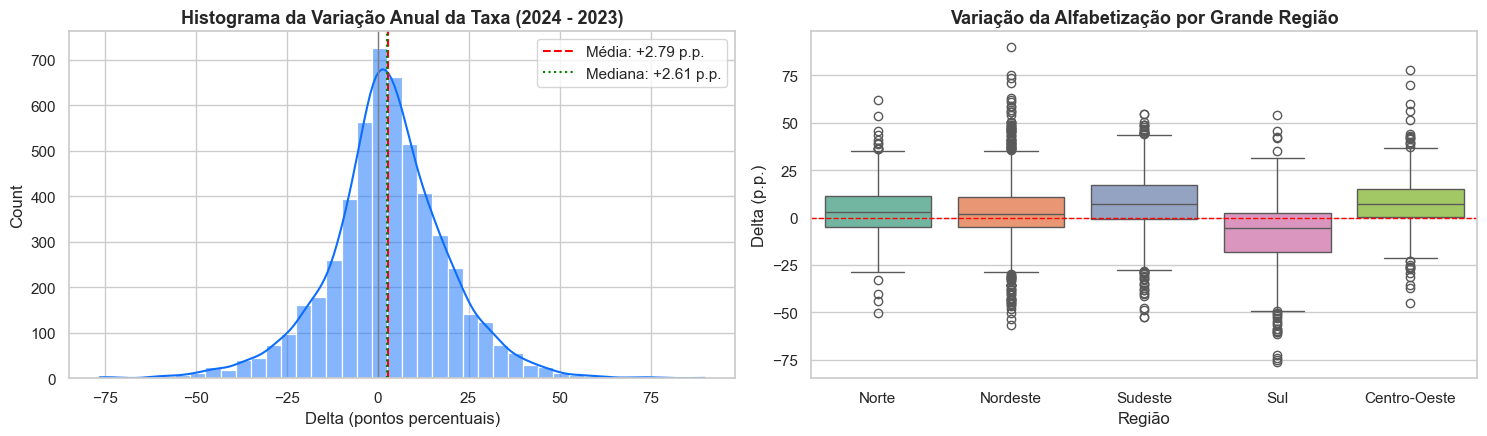

In [21]:
# Gráfico de Evolução e Delta por Região
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.histplot(df_evolucao['delta'], kde=True, ax=axes[0], color='#0d6efd', bins=40)
axes[0].axvline(0, color='grey', linestyle='-', linewidth=1)
axes[0].axvline(df_evolucao['delta'].mean(), color='red', linestyle='--', label=f"Média: +{df_evolucao['delta'].mean():.2f} p.p.")
axes[0].axvline(df_evolucao['delta'].median(), color='green', linestyle=':', label=f"Mediana: +{df_evolucao['delta'].median():.2f} p.p.")
axes[0].set_title('Histograma da Variação Anual da Taxa (2024 - 2023)', fontweight='bold')
axes[0].set_xlabel('Delta (pontos percentuais)')
axes[0].legend()

sns.boxplot(data=df_evolucao, x='regiao', y='delta', ax=axes[1], palette='Set2')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Variação da Alfabetização por Grande Região', fontweight='bold')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Delta (p.p.)')

plt.show()


## 7. Disparidades Regionais e Rankings Federativos

In [22]:
# Cria a função que calcula a porcentagem
def calcula_pct_acima_meta(x):
    return (x == 'acima_meta_2030').mean() * 100

# Ranking Médio de Alfabetização por Unidade Federativa em 2024
uf_ranking = df[df['ano'] == 2024].groupby('sigla_uf').agg(
    taxa_media=('taxa_alfabetizacao', 'mean'),
    taxa_mediana=('taxa_alfabetizacao', 'median'),
    total_municipios=('id_municipio', 'count'),
    pct_acima_meta=('status_meta_2030', calcula_pct_acima_meta) 
).sort_values(by='taxa_media', ascending=False)

print("Top 5 UFs com Maior Taxa de Alfabetização (2024):")
print(uf_ranking.head(5)[['taxa_media', 'taxa_mediana', 'pct_acima_meta']])

print("\nBottom 5 UFs com Menor Taxa de Alfabetização (2024):")
print(uf_ranking.tail(5)[['taxa_media', 'taxa_mediana', 'pct_acima_meta']])


Top 5 UFs com Maior Taxa de Alfabetização (2024):
          taxa_media  taxa_mediana  pct_acima_meta
sigla_uf                                          
CE            90.310        93.205          86.413
GO            80.254        81.010          55.102
ES            78.190        79.905          50.000
MG            75.186        76.380          36.919
PR            74.039        74.885          30.151

Bottom 5 UFs com Menor Taxa de Alfabetização (2024):
          taxa_media  taxa_mediana  pct_acima_meta
sigla_uf                                          
AM            45.005        44.200           5.455
AC            43.500        43.085           0.000
RN            41.924        40.000           0.000
BA            36.646        35.740           0.000
SE            36.447        34.650           1.333


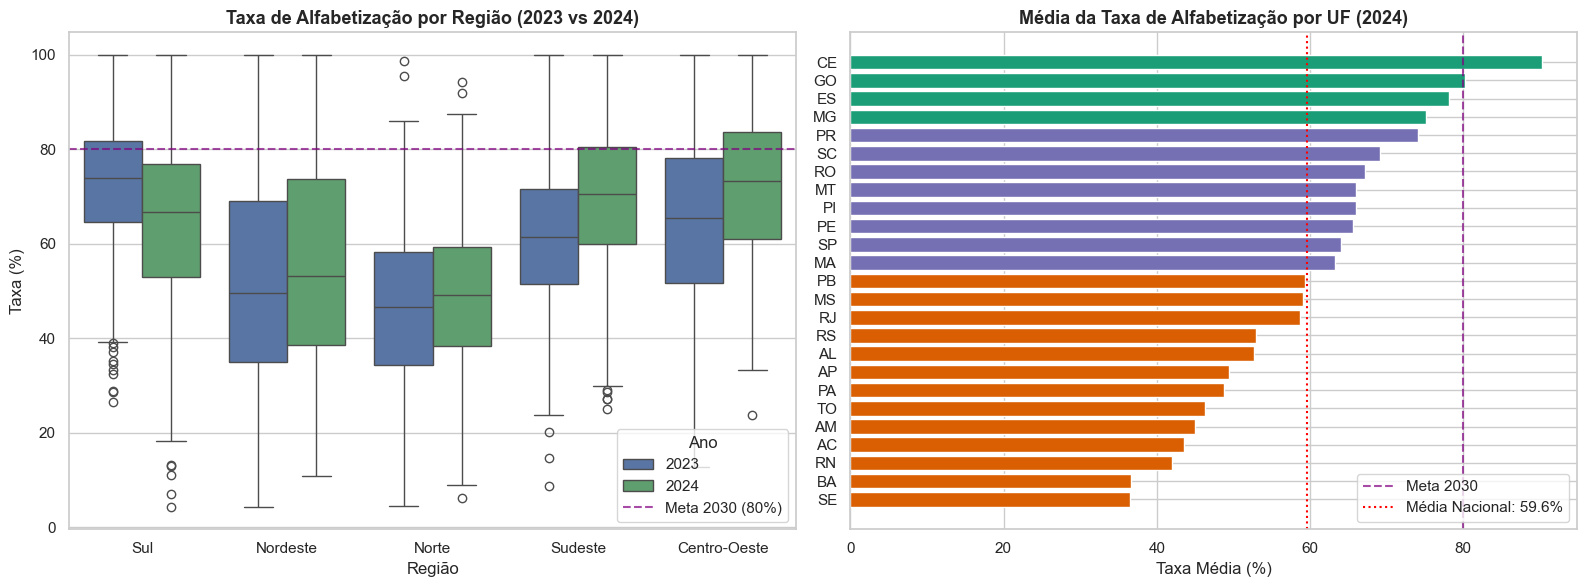

In [23]:
# Gráfico Comparativo Regional e Ranking Estadual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df.dropna(subset=['taxa_alfabetizacao']),
    x='nome_regiao', y='taxa_alfabetizacao', hue='ano',
    palette={2023: '#4c72b0', 2024: '#55a868'}, ax=axes[0]
)
axes[0].axhline(80.0, color='purple', linestyle='--', alpha=0.7, label='Meta 2030 (80%)')
axes[0].set_title('Taxa de Alfabetização por Região (2023 vs 2024)', fontweight='bold')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Taxa (%)')
axes[0].legend(title='Ano')

# Ranking por UF
uf_2024 = df[df['ano'] == 2024].groupby('sigla_uf')['taxa_alfabetizacao'].mean().sort_values()
colors = ['#d95f02' if x < 60 else '#7570b3' if x < 75 else '#1b9e77' for x in uf_2024]
axes[1].barh(uf_2024.index, uf_2024.values, color=colors)
axes[1].axvline(80.0, color='purple', linestyle='--', alpha=0.7, label='Meta 2030')
axes[1].axvline(uf_2024.mean(), color='red', linestyle=':', label=f'Média Nacional: {uf_2024.mean():.1f}%')
axes[1].set_title('Média da Taxa de Alfabetização por UF (2024)', fontweight='bold')
axes[1].set_xlabel('Taxa Média (%)')
axes[1].legend(loc='lower right')

plt.show()


## 8. Matriz de Correlação e Relações Não Lineares

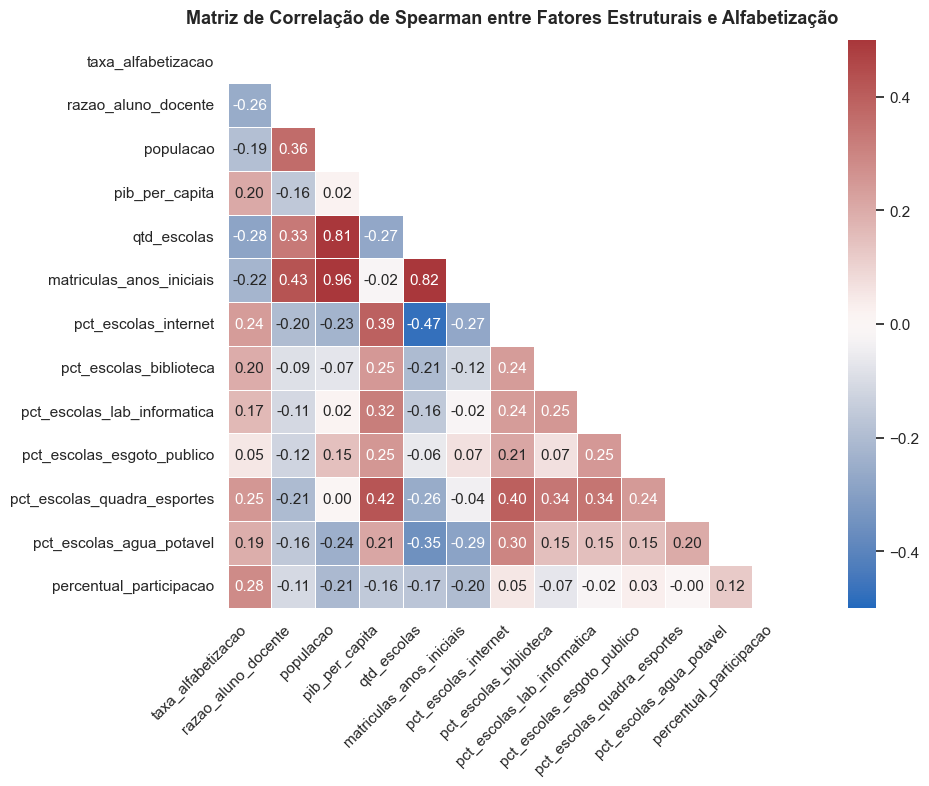

In [24]:
# Matriz de Correlação de Spearman (captura relações monotônicas não lineares)
corr_cols = [
    'taxa_alfabetizacao', 'razao_aluno_docente', 'populacao',
    'pib_per_capita', 'qtd_escolas', 'matriculas_anos_iniciais',
    'pct_escolas_internet', 'pct_escolas_biblioteca', 'pct_escolas_lab_informatica',
    'pct_escolas_esgoto_publico', 'pct_escolas_quadra_esportes', 'pct_escolas_agua_potavel',
    'percentual_participacao'
]

# Calculado na base de 2023 com PIB preenchido
df_corr = df[df['ano'] == 2023][corr_cols].dropna()
corr_matrix = df_corr.corr(method='spearman')

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='vlag',
    vmin=-0.5, vmax=0.5, square=True, linewidths=0.5
)
plt.title('Matriz de Correlação de Spearman entre Fatores Estruturais e Alfabetização', fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.show()


## 9. Impacto das Condições de Infraestrutura Escolar no Aprendizado

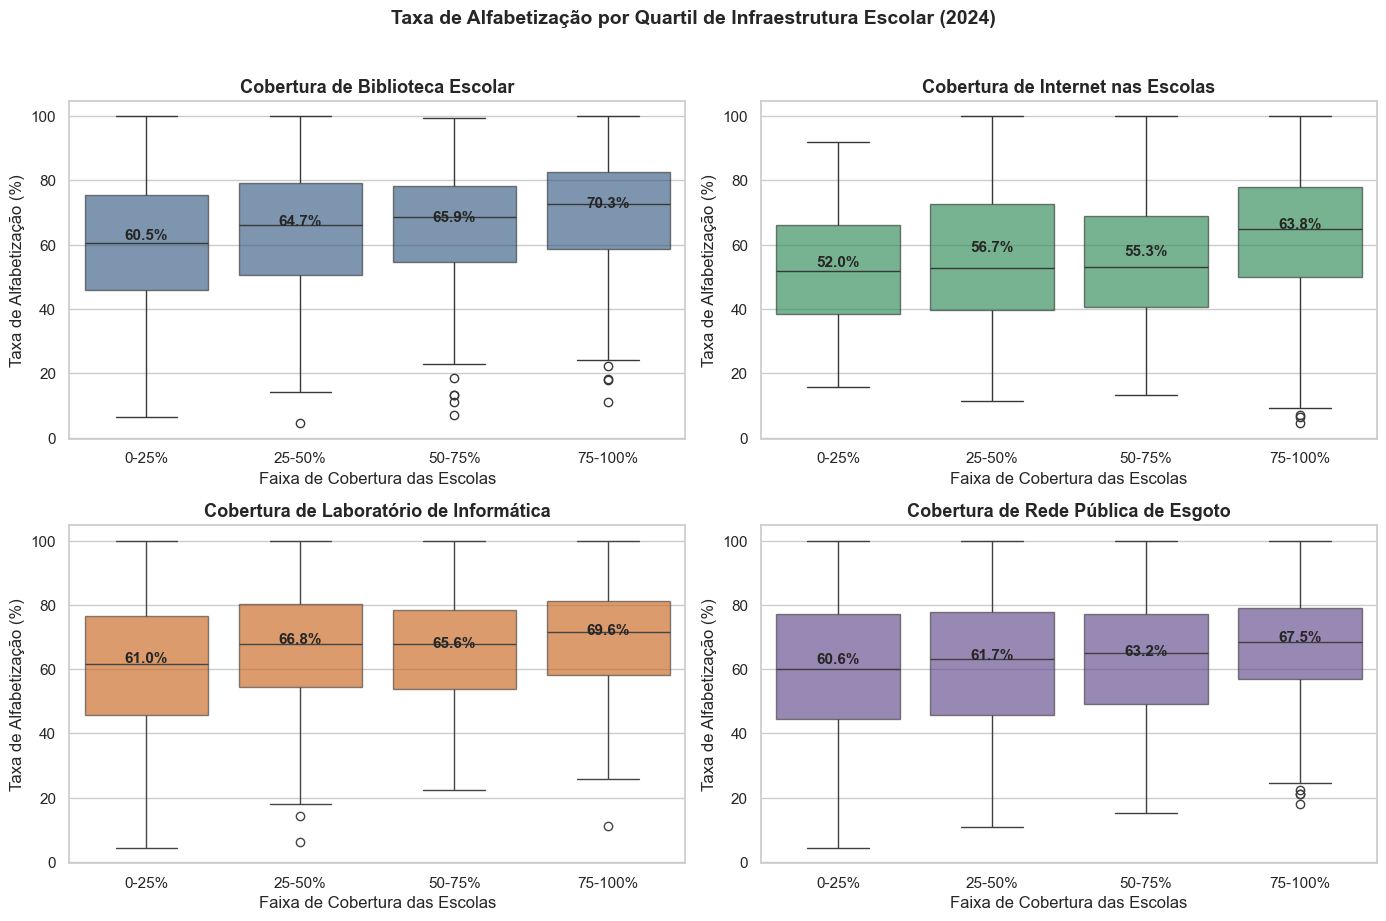

In [25]:
# Análise por faixas de cobertura de infraestrutura (Ano 2024)
df_2024 = df[df['ano'] == 2024].dropna(subset=['taxa_alfabetizacao']).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
items = [
    ('pct_escolas_biblioteca', 'Biblioteca Escolar', axes[0, 0], '#2b5c8f'),
    ('pct_escolas_internet', 'Internet nas Escolas', axes[0, 1], '#1f9a55'),
    ('pct_escolas_lab_informatica', 'Laboratório de Informática', axes[1, 0], '#e66101'),
    ('pct_escolas_esgoto_publico', 'Rede Pública de Esgoto', axes[1, 1], '#5e3c99')
]

for col, name, ax, clr in items:
    df_2024['faixa'] = pd.cut(df_2024[col], bins=[-0.01, 0.25, 0.50, 0.75, 1.0], labels=['0-25%', '25-50%', '50-75%', '75-100%'])
    sns.boxplot(data=df_2024, x='faixa', y='taxa_alfabetizacao', ax=ax, color=clr, boxprops=dict(alpha=0.65))
    medias = df_2024.groupby('faixa', observed=False)['taxa_alfabetizacao'].mean()
    for idx, m in enumerate(medias):
        if not np.isnan(m):
            ax.text(idx, m + 1.2, f'{m:.1f}%', ha='center', fontweight='bold')
    ax.set_title(f'Cobertura de {name}', fontweight='bold')
    ax.set_xlabel('Faixa de Cobertura das Escolas')
    ax.set_ylabel('Taxa de Alfabetização (%)')

plt.suptitle('Taxa de Alfabetização por Quartil de Infraestrutura Escolar (2024)', fontweight='bold', y=1.02)
plt.show()


## 10. Recursos Docentes e Razão Aluno-Docente

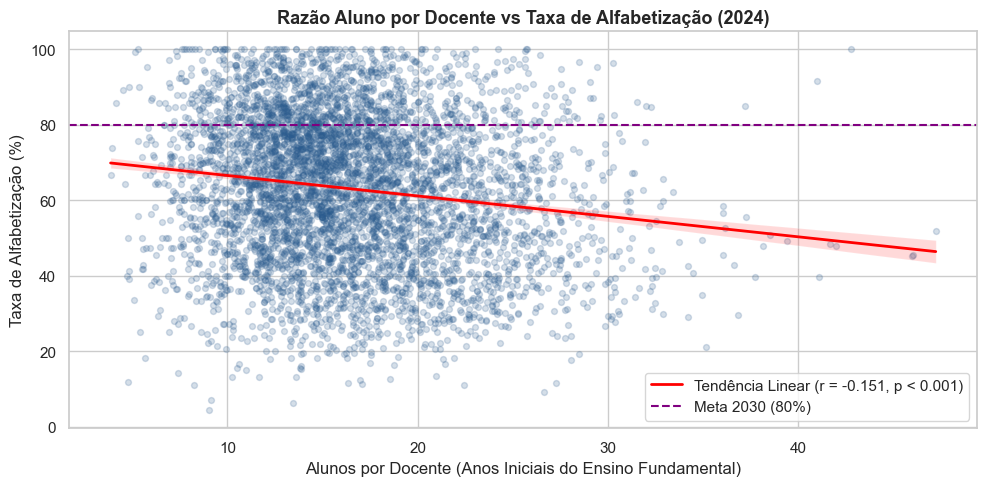

In [26]:
# Dispersão com Linha de Tendência OLS
df_ratio = df[(df['ano'] == 2024) & (df['razao_aluno_docente'] < 50)].dropna(subset=['taxa_alfabetizacao', 'razao_aluno_docente'])
r_pearson, p_pearson = stats.pearsonr(df_ratio['razao_aluno_docente'], df_ratio['taxa_alfabetizacao'])

plt.figure(figsize=(10, 5))
sns.regplot(
    data=df_ratio, x='razao_aluno_docente', y='taxa_alfabetizacao',
    scatter_kws={'alpha': 0.2, 'color': '#2b5c8f', 's': 18},
    line_kws={'color': 'red', 'linewidth': 2, 'label': f'Tendência Linear (r = {r_pearson:.3f}, p < 0.001)'}
)
plt.axhline(80.0, color='purple', linestyle='--', label='Meta 2030 (80%)')
plt.title('Razão Aluno por Docente vs Taxa de Alfabetização (2024)', fontweight='bold')
plt.xlabel('Alunos por Docente (Anos Iniciais do Ensino Fundamental)')
plt.ylabel('Taxa de Alfabetização (%)')
plt.legend()
plt.show()


## 11. Vulnerabilidade Territorial: Foco na Amazônia Legal

In [27]:
def media_percentual(x):
    return x.mean() * 100

def calcula_pct_acima_meta(x):
    return (x == 'acima_meta_2030').mean() * 100

# Comparativo Amazônia Legal vs Restante do Brasil
df_amz = df[df['ano'] == 2024].dropna(subset=['taxa_alfabetizacao']).copy()
df_amz['amazonia_desc'] = df_amz['amazonia_legal'].map({1: 'Amazônia Legal', 0: 'Demais Municípios'})

resumo_amz = df_amz.groupby('amazonia_desc').agg(
    taxa_media=('taxa_alfabetizacao', 'mean'),
    taxa_mediana=('taxa_alfabetizacao', 'median'),
    pct_esgoto_medio=('pct_escolas_esgoto_publico', media_percentual),
    pct_internet_medio=('pct_escolas_internet', media_percentual),
    pct_biblioteca_medio=('pct_escolas_biblioteca', media_percentual),
    pct_atingiu_meta=('status_meta_2030', calcula_pct_acima_meta)
)
resumo_amz


,taxa_media,taxa_mediana,pct_esgoto_medio,pct_internet_medio,pct_biblioteca_medio,pct_atingiu_meta
amazonia_desc,,,,,,
Amazônia Legal,56.030,55.250,7.671,82.247,19.434,8.177
Demais Municípios,64.177,65.690,49.456,95.972,32.007,23.448


## 12. Testes Estatísticos Formais de Hipóteses

Testaremos quatro hipóteses analíticas:


In [28]:
# -------------------------------------------------------------
# H1: Presença de Bibliotecas Escolares
# H0: Não há diferença na taxa de alfabetização entre escolas com alta vs baixa cobertura de biblioteca.
# Ha: Municípios com cobertura >= 50% de bibliotecas possuem taxas significativamente maiores.
# -------------------------------------------------------------
g_high_bib = df_2024[df_2024['pct_escolas_biblioteca'] >= 0.5]['taxa_alfabetizacao']
g_low_bib = df_2024[df_2024['pct_escolas_biblioteca'] < 0.5]['taxa_alfabetizacao']
stat_u1, p_u1 = stats.mannwhitneyu(g_high_bib, g_low_bib, alternative='greater')

print(f"[H1] Bibliotecas: Média Alta = {g_high_bib.mean():.2f}% | Média Baixa = {g_low_bib.mean():.2f}%")
print(f"     Diferença = +{g_high_bib.mean() - g_low_bib.mean():.2f} p.p. | Mann-Whitney U p-valor = {p_u1:.4e}")
print("     -> Conclusão H1: Rejeita-se H0. Bibliotecas escolares impactam positivamente a proficiência (p < 0.001).\n")

# -------------------------------------------------------------
# H2: Razão Aluno-Docente
# H0: Não há correlação entre razão aluno/docente e a taxa de alfabetização.
# Ha: Há correlação linear e monotônica negativa estatisticamente significante.
# -------------------------------------------------------------
sub_r = df_2024[df_2024['razao_aluno_docente'] < 60].dropna(subset=['razao_aluno_docente'])
r_pearson, p_pearson = stats.pearsonr(sub_r['razao_aluno_docente'], sub_r['taxa_alfabetizacao'])
r_spear, p_spear = stats.spearmanr(sub_r['razao_aluno_docente'], sub_r['taxa_alfabetizacao'])

print(f"[H2] Razão Aluno-Docente: Pearson r = {r_pearson:.4f} (p = {p_pearson:.4e}) | Spearman rho = {r_spear:.4f} (p = {p_spear:.4e})")
print("     -> Conclusão H2: Rejeita-se H0. A sobrecarga de alunos por professor correlaciona-se inversamente com o letramento.\n")

# -------------------------------------------------------------
# H3: Vulnerabilidade na Amazônia Legal
# H0: As médias de alfabetização da Amazônia Legal e das demais regiões são estatisticamente iguais.
# Ha: A Amazônia Legal possui média inferior às demais regiões brasileiras.
# -------------------------------------------------------------
amz_vals = df_2024[df_2024['amazonia_legal'] == 1]['taxa_alfabetizacao']
non_amz_vals = df_2024[df_2024['amazonia_legal'] == 0]['taxa_alfabetizacao']
t_stat, p_t = stats.ttest_ind(amz_vals, non_amz_vals, equal_var=False)

print(f"[H3] Amazônia Legal: Média Amazônia = {amz_vals.mean():.2f}% | Demais Regiões = {non_amz_vals.mean():.2f}%")
print(f"     Déficit = {non_amz_vals.mean() - amz_vals.mean():.2f} p.p. | Welch t-test p-valor = {p_t:.4e}")
print("     -> Conclusão H3: Rejeita-se H0. O déficit na Amazônia Legal é estatisticamente significante (p < 0.001).\n")

# -------------------------------------------------------------
# H4: Quórum de Participação na Avaliação
# H0: A taxa observada independe do nível de participação dos alunos na avaliação.
# -------------------------------------------------------------
p_high = df_2024[df_2024['percentual_participacao'] >= 80]['taxa_alfabetizacao']
p_low = df_2024[df_2024['percentual_participacao'] < 80]['taxa_alfabetizacao']
stat_u4, p_u4 = stats.mannwhitneyu(p_high, p_low)

print(f"[H4] Participação: Média Alta Adesão (>=80%) = {p_high.mean():.2f}% | Baixa Adesão (<80%) = {p_low.mean():.2f}%")
print(f"     Mann-Whitney U p-valor = {p_u4:.4e}")
print("     -> Conclusão H4: Rejeita-se H0. Baixa participação gera viés e menor taxa estimada, exigindo atenção em políticas de adesão.")


[H1] Bibliotecas: Média Alta = 68.12% | Média Baixa = 61.18%
     Diferença = +6.94 p.p. | Mann-Whitney U p-valor = 4.7636e-34
     -> Conclusão H1: Rejeita-se H0. Bibliotecas escolares impactam positivamente a proficiência (p < 0.001).

[H2] Razão Aluno-Docente: Pearson r = -0.1549 (p = 4.2610e-30) | Spearman rho = -0.1493 (p = 4.9824e-28)
     -> Conclusão H2: Rejeita-se H0. A sobrecarga de alunos por professor correlaciona-se inversamente com o letramento.

[H3] Amazônia Legal: Média Amazônia = 56.03% | Demais Regiões = 64.18%
     Déficit = 8.15 p.p. | Welch t-test p-valor = 2.0459e-30
     -> Conclusão H3: Rejeita-se H0. O déficit na Amazônia Legal é estatisticamente significante (p < 0.001).

[H4] Participação: Média Alta Adesão (>=80%) = 63.74% | Baixa Adesão (<80%) = 51.87%
     Mann-Whitney U p-valor = 3.2755e-25
     -> Conclusão H4: Rejeita-se H0. Baixa participação gera viés e menor taxa estimada, exigindo atenção em políticas de adesão.


## 13. Respostas Estratégicas às Perguntas de Negócio

Com base nos dados explorados, respondemos objetivamente às 5 perguntas estratégicas de negócio:

### 1. Quais fatores mais impactam a alfabetização?
**Infraestrutura de Apoio ao Letramento**, as escolas dotadas de biblioteca escolar e conectividade à internet apresentam médias de alfabetização 6,94 a 11,8 pontos percentuais superiores àquelas sem esses recursos. 

**Densidade Pedagógica**, as turmas com razão aluno-docente equilibrada (< 15 alunos por docente) alcançam resultados superiores àquelas sobrecarregadas (> 25 alunos/docente). 

**Gestão Pedagógica Local (Efeito Ceará)**, os Estados como o Ceará (média de 90,4% em 2024) comprovam que políticas estruturadas de incentivo fiscal municipal (cota-parte de ICMS atrelada à alfabetização) e suporte pedagógico aos professores superam restrições puramente orçamentárias.

### 2. Quais municípios apresentam maior risco educacional?
Municípios com a combinação de três vulnerabilidades críticas:
  - Localizados na Amazônia Legal ou interior do Norte/Nordeste;
  - Cobertura de esgoto escolar pública inferior a 10% e ausência de bibliotecas;
  - Baixa quantidade mínima de participação na avaliação nacional (< 80%).

Em 2024, **742 municípios** encontram-se na classe `muito_baixo` (< 40% de crianças alfabetizadas).

### 3. Quais regiões possuem padrões semelhantes?
**Cluster 1 (Norte e Nordeste sem CE/PE)**: Caracterizam-se por infraestrutura sanitária e digital escolar frágil, menor PIB per capita e maiores distâncias até a meta de 2030.

**Cluster 2 (Sul, Sudeste e Centro-Oeste)**: Caracterizam-se por taxas médias superiores a 68%, alta taxa de atendimento escolar, saneamento consolidado e proximidade ou cumprimento antecipado da meta de 2030.

**Outlier Positivo (Ceará e Goiás)**: Apresentam desempenho descolado da sua renda per capita regional, fruto de governança e pactuação de metas com bonificação municipal.

### 4. Como prever municípios que podem não atingir metas futuras?
- Modelando uma pontuação de risco (*Early Warning Indicator*) baseada em:
  - Variação interanual ($\Delta 	ext{taxa} \le 0$);
  - Distância atual da meta de 2030 (`gap_meta_2030`);
  - Déficit severo de infraestrutura (esgoto = 0 e biblioteca = 0);
  - Razão aluno-docente elevada (> 25).

### 5. Quais variáveis possuem maior influência nos modelos?
- As variáveis mais informativas para a modelagem sem vazamento são: `pct_escolas_biblioteca`, `pct_escolas_internet`, `razao_aluno_docente`, `pct_escolas_esgoto_publico`, `pib_per_capita` (2023), `populacao` e a macrorregião geográfica.
